In [1]:
import osmnx as ox
from scgraph.geograph import GeoGraph

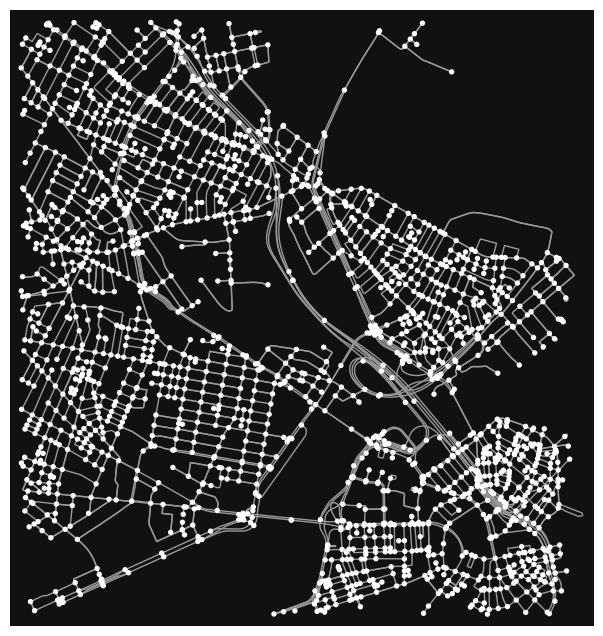

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
# Download the street network inside the bounding box
local_graph = ox.graph_from_bbox(
    bbox=[-71.1, 42.355, -71.05, 42.395],
    network_type='drive',
    # network_type='bike',
    # network_type='all_public',
    simplify=True,
    # Get all roads down to secondary.
    # custom_filter = (
    #     '["highway"~"motorway|motorway_link|trunk|trunk_link|primary|primary_link|secondary"]'
    # )
)

local_graph = ox.add_edge_speeds(local_graph)
local_graph = ox.add_edge_travel_times(local_graph)

ox.plot_graph(local_graph)

In [ ]:
geograph = GeoGraph.load_from_osmnx_graph(
    osmnx_graph=local_graph, 
    # weight_key='length',
    weight_key='travel_time',
    off_graph_travel_speed=15,  # in km/h
    coord_precision=6,
    load_intermediate_nodes=True,
)


In [4]:
# A simple example of how to use folium to visualize the shortest path between two points
import folium

# Get the shortest path between Winter Hill in Somerville and the MIT CTL in Cambridge
folium_output = geograph.get_shortest_path(
    origin_node={'latitude': 42.3906, 'longitude': -71.0961}, # Winter Hill, Somerville
    destination_node={'latitude': 42.361, 'longitude': -71.084}, # MIT CTL, Cambridge
)

# Folium does not wrap coordinates around the globe, so we need to adjust the path accordingly
# Essentially we create 5 differnt paths that offset the original path by 0, 360, -360, 720, -720 degrees
# This allows the illusion that the path wraps around the globe with folium
def adjustArcPath(path):
    for index in range(1, len(path)):
        x = path[index][1]
        prevX = path[index - 1][1]
        path[index][1] = x - (round((x - prevX)/360,0) * 360)
    return path

def modifyArcPathLong(points, amount):
    return [[i[0], i[1]+amount] for i in points]

def getCleanArcPath(path):
    path = adjustArcPath(path)
    return [
        path,
        modifyArcPathLong(path, 360),
        modifyArcPathLong(path, -360),
        modifyArcPathLong(path, 720),
        modifyArcPathLong(path, -720)
    ]

# Create a folium map
map = folium.Map([42.361, -71.084], zoom_start=14)
# Populate it with the path
folium.PolyLine(
    getCleanArcPath(folium_output['coordinate_path']),
    color='green',
    weight=5,
    opacity=0.5,
    popup='Expected Length (KM): ' + str(folium_output['length'])
).add_to(map)
map